In [1]:
import h5ify
import matplotlib.pyplot as plt

In [2]:
result = h5ify.load('/n/home03/newolfe/projects/tilts-and-kicks/data/inference/pixelpop/vi/ct-nb10-lr1e-3-flr1e-3-s1e4-b10-bd64/result.h5')

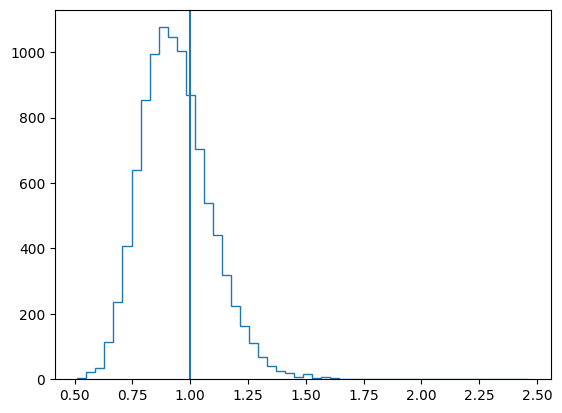

In [5]:
fig, ax = plt.subplots()
ax.hist(result['variance'], histtype='step', bins=50)
ax.axvline(x=1);

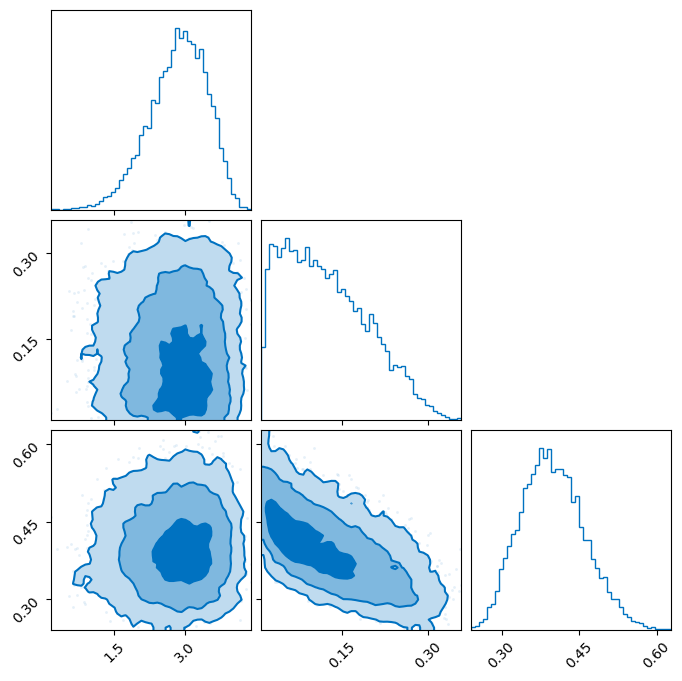

In [8]:
from util import plot_corner
import numpy as np

fig = plot_corner(np.column_stack([
    result['lamb'],
    result['mu_chi'],
    result['sigma_chi']
]))

In [10]:
ln_m1s = np.array([1.09861229, 1.55912931, 2.01964633, 2.48016334, 2.94068036,
       3.40119738, 3.8617144 , 4.32223142, 4.78274844, 5.24326546,
       5.70378247])
cts = np.array([-1. , -0.8, -0.6, -0.4, -0.2,  0. ,  0.2,  0.4,  0.6,  0.8,  1. ])

In [13]:
ln_rate = result['log_merger_rate_density']

In [60]:
samples = dict(log_merger_rate_density=result['log_merger_rate_density'], lamb=result['lamb'])

In [61]:
from util import logtrapz
import jax

from astropy.cosmology import Planck15
from astropy import units

z0 = 0.2

ln_dvc_dz = np.log(
    4*np.pi*Planck15.differential_comoving_volume(z0).to(units.Gpc**3 / units.sr).value
)
postfactor = ln_dvc_dz + np.log(1 + z0)

dx = ln_m1s[1] - ln_m1s[0]

ln_ct = jax.vmap(
    lambda x: logtrapz(
        x['log_merger_rate_density'] - postfactor + x['lamb'] * np.log(1 + z0),
        dx=dx,
        axis=0
    )
)(samples)

dx = cts[1] - cts[0]

ln_lnm1 = jax.vmap(
    lambda x: logtrapz(
        x['log_merger_rate_density'] - postfactor + x['lamb'] * np.log(1 + z0),
        dx=dx,
        axis=1
    )
)(samples)

In [70]:
def get_span_bins(xs, ys):
    """ expand and reshape x, y so that we have y over each [x, x+dx] """
    ns, ny = ys.shape

    ws = np.zeros(2 * ny)
    ws[0::2] = xs[:-1]
    ws[1::2] = xs[1:]

    zs = np.zeros((ns, 2 * ny))
    zs[:, 0::2] = ys
    zs[:, 1::2] = ys

    return ws, zs

In [71]:
xs, ys = get_span_bins(cts, ln_ct)

Text(0, 0.5, '$\\mathcal{R}(\\cos \\tau_{1,2}; z = 0.2)$ [$\\mathrm{Gpc}^{-3} \\, \\mathrm{yr}^{-1}$]')

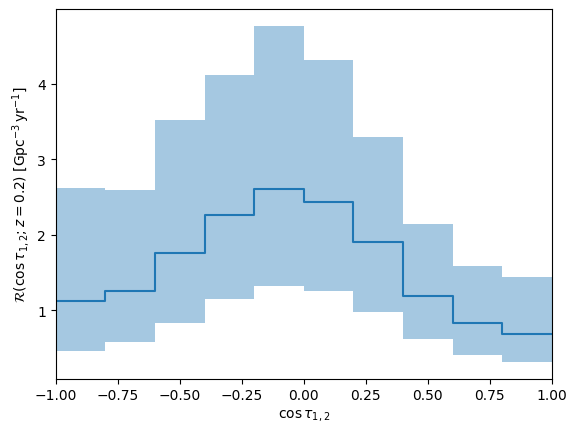

In [73]:
fig, ax = plt.subplots()

ax.plot(
    xs,
    np.exp(np.median(ys, axis=0))
)

ax.fill_between(
    xs,
    np.exp(np.quantile(ys, 0.05, axis=0)),
    np.exp(np.quantile(ys, 0.95, axis=0)),
    alpha=0.4,
    color='C0',
    linewidth=0
)

ax.set_xlim(-1, 1)

ax.set_xlabel(r'$\cos \tau_{1,2}$')

ax.set_ylabel(r'$\mathcal{R}(\cos \tau_{1,2}; z = 0.2)$ [$\mathrm{Gpc}^{-3} \, \mathrm{yr}^{-1}$]')

Text(0, 0.5, '$m_1 \\mathcal{R}(m_1; z = 0.2)$ [$\\mathrm{Gpc}^{-3} \\, \\mathrm{yr}^{-1}$]')

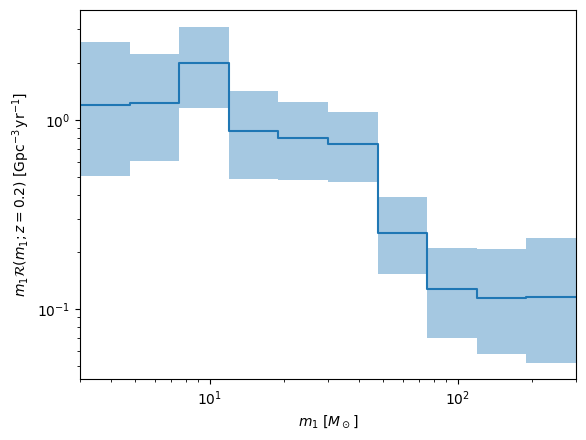

In [74]:
xs, ys = get_span_bins(ln_m1s, ln_lnm1)
fig, ax = plt.subplots()

ax.plot(
    np.exp(xs),
    np.exp(np.median(ys, axis=0))
)

ax.fill_between(
    np.exp(xs),
    np.exp(np.quantile(ys, 0.05, axis=0)),
    np.exp(np.quantile(ys, 0.95, axis=0)),
    alpha=0.4,
    color='C0',
    linewidth=0
)

ax.set_yscale('log')
ax.set_xscale('log')

ax.set_xlim(3, 300)

ax.set_xlabel(r'$m_1$ [$M_\odot$]')
ax.set_ylabel(r'$m_1 \mathcal{R}(m_1; z = 0.2)$ [$\mathrm{Gpc}^{-3} \, \mathrm{yr}^{-1}$]')

In [79]:
joint_median

array([[ 2.522598  ,  2.41006398,  2.69691326,  2.70022582,  2.87995558,
         2.73947027,  2.5522404 ,  2.24477917,  2.02557819,  1.80815368],
       [ 2.29275789,  2.50469676,  2.73598812,  3.0179285 ,  3.06774136,
         3.04485256,  2.67984363,  2.24080371,  1.94400641,  1.75479081],
       [ 2.23160441,  2.45052809,  2.92689542,  3.42362172,  3.73907245,
         3.76913633,  3.63575258,  3.0964565 ,  2.44384986,  1.89303627],
       [ 1.96828221,  2.14063571,  2.43231992,  2.70907001,  2.74188461,
         2.70823439,  2.43471758,  2.01788234,  1.72791169,  1.51381325],
       [ 1.84337423,  1.98560521,  2.50404664,  2.71929094,  2.79098722,
         2.61926965,  2.26132044,  1.81976698,  1.44610675,  1.29818674],
       [ 1.63510561,  1.96323443,  2.3859237 ,  2.64233168,  2.8048937 ,
         2.64997803,  2.30277027,  1.70352066,  1.36348019,  1.4177525 ],
       [ 0.96732662,  1.10256331,  1.16494081,  1.32359638,  1.35253916,
         1.30929883,  1.1335084 ,  0.80162282

In [86]:
joint.max()

np.float64(0.5219874478338697)

Text(0, 0.5, '$\\mathcal{R}(m_1, \\cos \\tau_{1,2}; z = 0.2)$ [$\\mathrm{Gpc}^{-3}\\, \\mathrm{yr}^{-1}$]')

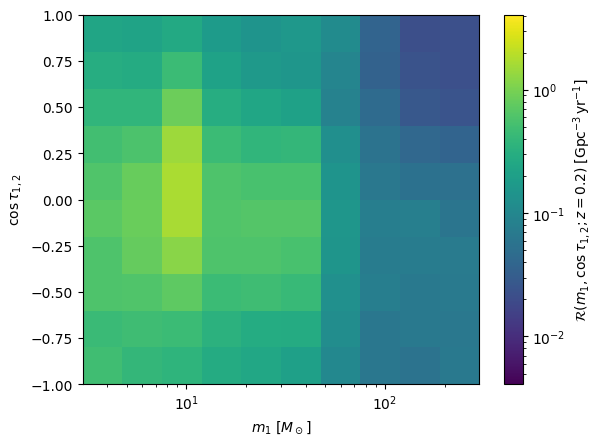

In [104]:
from matplotlib.colors import LogNorm

z0 = 0.2

ln_dvc_dz = np.log(
    4*np.pi*Planck15.differential_comoving_volume(z0).to(units.Gpc**3 / units.sr).value
)
postfactor = ln_dvc_dz + np.log(1 + z0)

joint = np.median(ln_rate - postfactor + result['lamb'][:, None, None] * np.log(1 + z0), axis=0)

mm, cc = np.meshgrid(ln_m1s, cts, indexing='ij')

fig, ax = plt.subplots()
sm = ax.pcolormesh(
    np.exp(mm),
    cc,
    np.exp(joint),
    norm=LogNorm(vmin=np.exp(-5.5), vmax=np.exp(1.4))
)
ax.set_xscale('log')

ax.set_ylabel(r'$\cos \tau_{1,2}$')
ax.set_xlabel(r'$m_1$ [$M_\odot$]')

cbar = fig.colorbar(sm)
cbar.ax.set_ylabel(r'$\mathcal{R}(m_1, \cos \tau_{1,2}; z = 0.2)$ [$\mathrm{Gpc}^{-3}\, \mathrm{yr}^{-1}$]')

Text(0, 0.5, '$\\mathcal{R}(m_1, \\cos \\tau_{1,2}; z = 0.2)$ [$\\mathrm{Gpc}^{-3}\\, \\mathrm{yr}^{-1}$]')

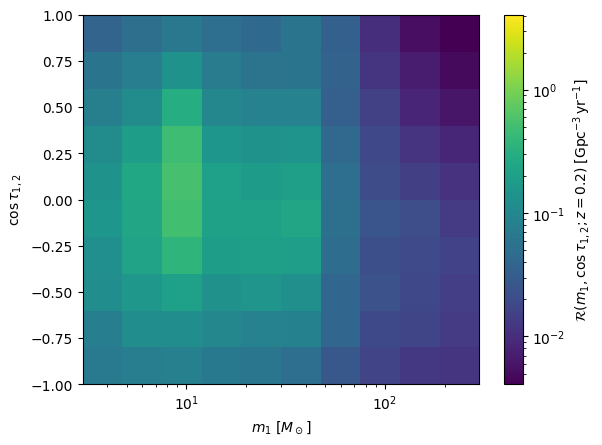

In [103]:
from matplotlib.colors import LogNorm

z0 = 0.2

ln_dvc_dz = np.log(
    4*np.pi*Planck15.differential_comoving_volume(z0).to(units.Gpc**3 / units.sr).value
)
postfactor = ln_dvc_dz + np.log(1 + z0)

joint = np.quantile(ln_rate - postfactor + result['lamb'][:, None, None] * np.log(1 + z0), 0.05, axis=0)

mm, cc = np.meshgrid(ln_m1s, cts, indexing='ij')

fig, ax = plt.subplots()
sm = ax.pcolormesh(
    np.exp(mm),
    cc,
    np.exp(joint),
    norm=LogNorm(vmin=np.exp(-5.5), vmax=np.exp(1.4))
)
ax.set_xscale('log')

ax.set_ylabel(r'$\cos \tau_{1,2}$')
ax.set_xlabel(r'$m_1$ [$M_\odot$]')

cbar = fig.colorbar(sm)
cbar.ax.set_ylabel(r'$\mathcal{R}(m_1, \cos \tau_{1,2}; z = 0.2)$ [$\mathrm{Gpc}^{-3}\, \mathrm{yr}^{-1}$]')

Text(0, 0.5, '$\\mathcal{R}(m_1, \\cos \\tau_{1,2}; z = 0.2)$ [$\\mathrm{Gpc}^{-3}\\, \\mathrm{yr}^{-1}$]')

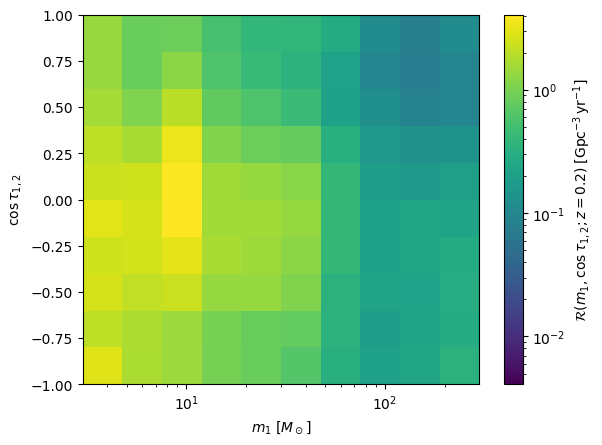

In [102]:
from matplotlib.colors import LogNorm

z0 = 0.2

ln_dvc_dz = np.log(
    4*np.pi*Planck15.differential_comoving_volume(z0).to(units.Gpc**3 / units.sr).value
)
postfactor = ln_dvc_dz + np.log(1 + z0)

joint = np.quantile(ln_rate - postfactor + result['lamb'][:, None, None] * np.log(1 + z0), 0.95, axis=0)

mm, cc = np.meshgrid(ln_m1s, cts, indexing='ij')

fig, ax = plt.subplots()
sm = ax.pcolormesh(
    np.exp(mm),
    cc,
    np.exp(joint),
    norm=LogNorm(vmin=np.exp(-5.5), vmax=np.exp(1.4))
)
ax.set_xscale('log')

ax.set_ylabel(r'$\cos \tau_{1,2}$')
ax.set_xlabel(r'$m_1$ [$M_\odot$]')

cbar = fig.colorbar(sm)
cbar.ax.set_ylabel(r'$\mathcal{R}(m_1, \cos \tau_{1,2}; z = 0.2)$ [$\mathrm{Gpc}^{-3}\, \mathrm{yr}^{-1}$]')